# Predikcija zadovoljstva putnika avio-kompanije primenom neuronskih mreža i algoritama mašinskog učenja

Koristiće se:
- Logistička regresija
- Random Forest
- Višeslojna neuronska mreža (MLP)

# Biblioteke

In [238]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [239]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Priprema podataka

In [240]:
# Nepotrebne kolone uklanjamo
train_df.drop(columns=['id', 'Unnamed: 0'], inplace=True)
test_df.drop(columns=['id', 'Unnamed: 0'], inplace=True)

In [241]:
# Na osnovu zadnjih analiza, vidimo da su neke od kolona koje predstavljaju usluge avio kompanije imale vrednost 0, sto nije primenljivo. 
# Ove vrednosti cemo zameniti sa NaN, a zatim popuniti sa medianom.
service_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

train_df[service_cols] = train_df[service_cols].replace(0, np.nan)
test_df[service_cols] = test_df[service_cols].replace(0, np.nan)
median = train_df[service_cols].median()

train_df[service_cols] = train_df[service_cols].fillna(median)
test_df[service_cols] = test_df[service_cols].fillna(median)

In [242]:
# Na osnovu korelacione matrice iz EDA, brišemo Arrival Delay in Minutes, jer je visoko korelisana sa Departure Delay in Minutes
train_df.drop(columns=['Arrival Delay in Minutes'], inplace=True)
test_df.drop(columns=['Arrival Delay in Minutes'], inplace=True)

In [243]:
# Kodiranje kategorickih kolona-One Hot Encoding
categorical_cols = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class'
]

train_df = pd.get_dummies(train_df, columns=categorical_cols, dtype=int , drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, dtype=int , drop_first=True)

In [244]:
# Kako bi se osigurali da train i test skup imaju iste kolone nakon one hot encoding-a, koristimo align funkciju
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)


In [245]:
print("Kolone se poklapaju:", test_df.columns.equals(train_df.columns))

Kolone se poklapaju: True


In [246]:
le = LabelEncoder()

train_df['satisfaction'] = le.fit_transform(train_df['satisfaction'])
test_df['satisfaction'] = le.transform(test_df['satisfaction'])

In [247]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}


In [248]:
# Train test split
X_train = train_df.drop('satisfaction', axis=1)
y_train = train_df['satisfaction']

X_test = test_df.drop('satisfaction', axis=1)
y_test = test_df['satisfaction']

In [249]:
num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes']

scaler = StandardScaler()

# Skaliramo samo numeričke kontinualne kolone
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Logistička regresija

In [250]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     14573
           1       0.87      0.87      0.87     11403

    accuracy                           0.89     25976
   macro avg       0.88      0.88      0.88     25976
weighted avg       0.89      0.89      0.89     25976



Klasa 0: neutral/dissatisfied

Precision: Kada model predvidi da je putnik nezadovoljan ili neutralan, u 90% slučajeva je u pravu.
Recall: Model uspeva da pronađe oko 90% svih stvarno nezadovoljnih ili neutralnih putnika.

Klasa 1: satisfied

Precision: Kada model proceni da je putnik zadovoljan, ta procena je tačna u 87% slučajeva.
Recall: Model uspeva da prepozna oko 87% svih stvarno zadovoljnih putnika.

F1-score (0.90 i 0.87): Model ostvaruje solidne rezultate za obe klase, ali zaostaje za složenijim modelima jer ne može u potpunosti da uhvati nelinearne odnose između obeležja. Zbog toga se koristi kao bazni model za poređenje sa Random Forest algoritmom i neuronskim mrežama.


Matrica konfuzije za logističku regresiju

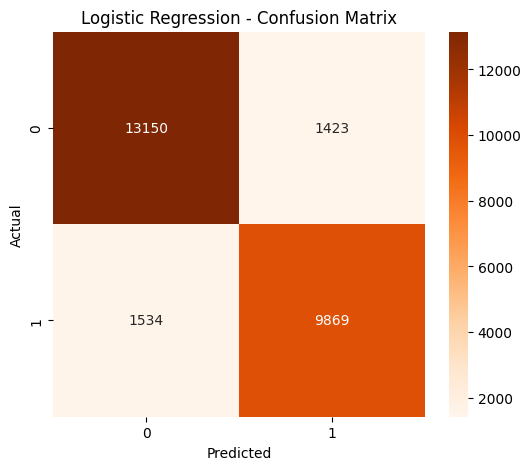

In [251]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sb.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Random Forest

In [252]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))




              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14573
           1       0.97      0.93      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



Klasa 0: neutral/dissatisfied

Precision: Kada model kaže da je putnik nezadovoljan, u 95% slučajeva je u pravu

Recall: Model uspeva da pronađe čak 98% svih stvarno nezadovoljnih putnika

Klasa 1: satisfied

Precision: Model je precizan, 97% slucajeva pogodi da je putnik zadovoljan

Recall: Modelu promakne oko 7% zadovoljnih putnika

F1-score (0.96 i 0.95): Pošto su obe vrednosti izuzetno blizu, model je stabilan i podjednako dobro prepoznaje i jedne i druge putnike

Matrica konfuzije za random forest

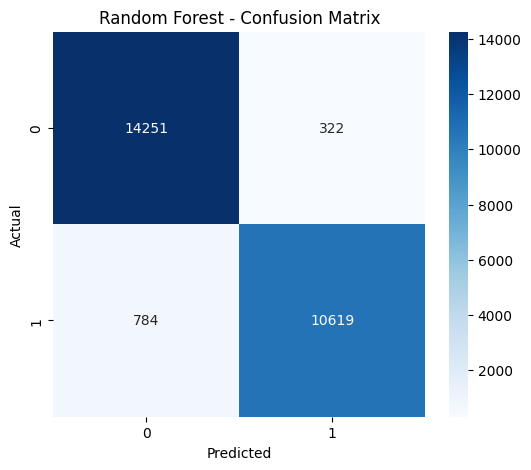

In [253]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sb.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [254]:
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                           feature  importance
7                  Online boarding    0.209368
19  Type of Travel_Personal Travel    0.111238
2            Inflight wifi service    0.109857
20                       Class_Eco    0.073775
9           Inflight entertainment    0.055330
8                     Seat comfort    0.047304
1                  Flight Distance    0.040447
11                Leg room service    0.037800
0                              Age    0.036703
10                On-board service    0.033598


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_5524\187285070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='importance', y='feature', data=feat_imp.head(10), palette='viridis')


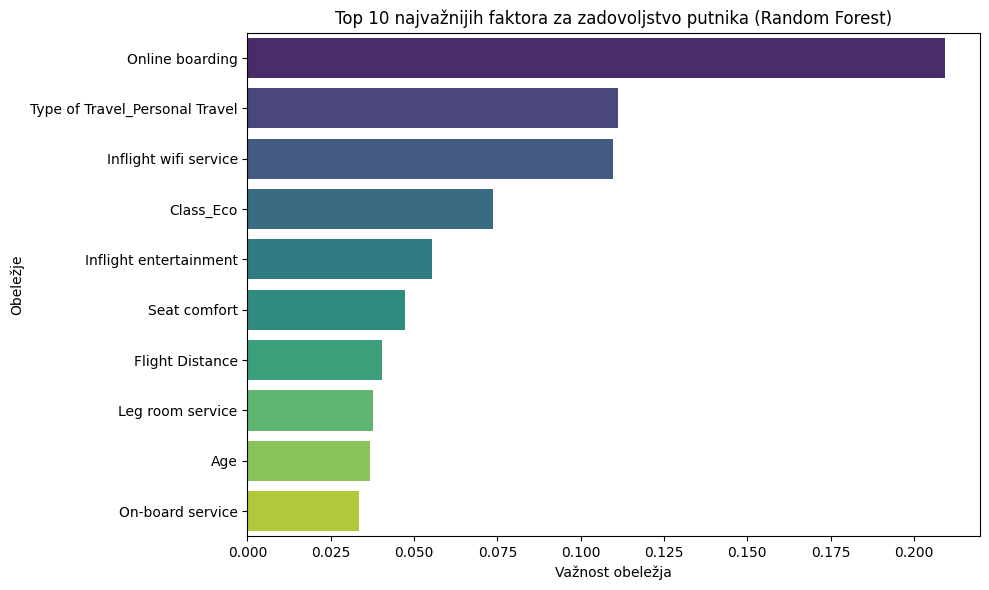

In [255]:
plt.figure(figsize=(10, 6))
sb.barplot(x='importance', y='feature', data=feat_imp.head(10), palette='viridis')
plt.title('Top 10 najvažnijih faktora za zadovoljstvo putnika (Random Forest)')
plt.xlabel('Važnost obeležja')
plt.ylabel('Obeležje')
plt.tight_layout()
plt.show()

# Osnovna MLP neuronska mreža

In [256]:
input_dim = X_train.shape[1]

mlp = Sequential()
mlp.add(Input(shape=(input_dim,)))
mlp.add(Dense(64, activation='relu'))
mlp.add(Dense(32, activation='relu'))
mlp.add(Dense(1, activation='sigmoid'))

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8861 - loss: 0.2675 - val_accuracy: 0.9126 - val_loss: 0.2261
Epoch 2/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9171 - loss: 0.2016 - val_accuracy: 0.9237 - val_loss: 0.1813
Epoch 3/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9250 - loss: 0.1831 - val_accuracy: 0.9123 - val_loss: 0.1932
Epoch 4/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9282 - loss: 0.1741 - val_accuracy: 0.9380 - val_loss: 0.1547
Epoch 5/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9327 - loss: 0.1636 - val_accuracy: 0.9313 - val_loss: 0.1599
Epoch 6/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9355 - loss: 0.1580 - val_accuracy: 0.9333 - val_loss: 0.1541
Epoch 7/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9366 - loss: 0.1522 - val_accuracy: 0.9409 - val_loss: 0.1386
Epoch 8/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9388 - loss: 0.1482 - 

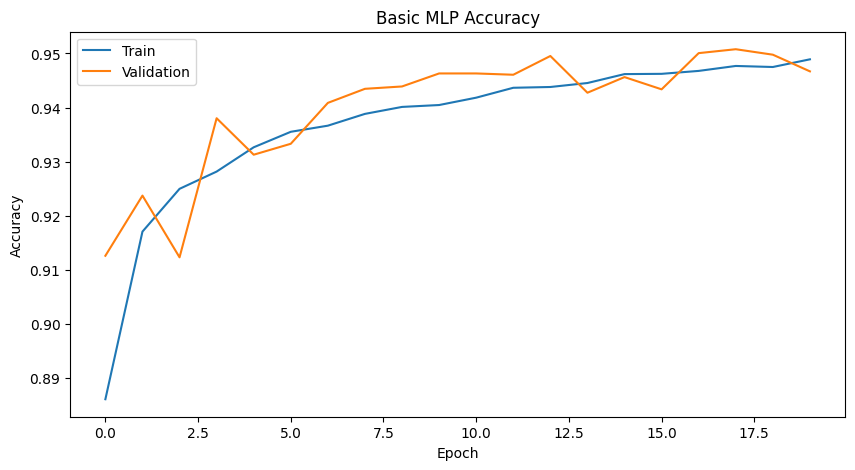

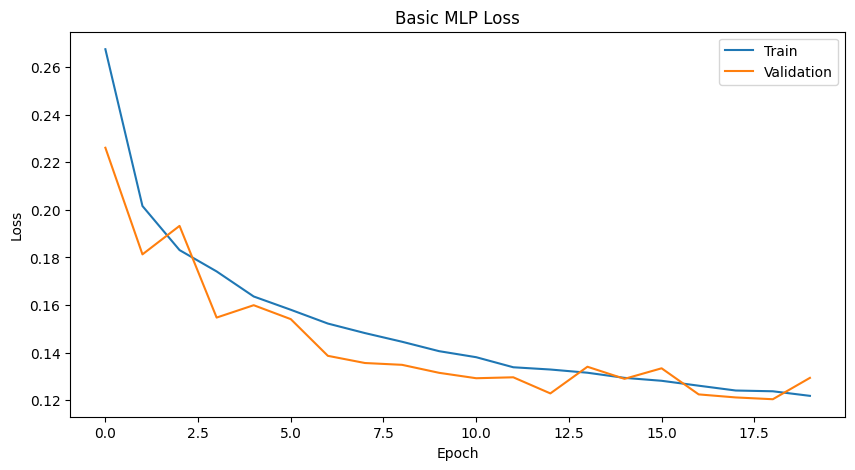

In [257]:
mlp.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
mlp.summary()
history_basic = mlp.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Accuracy

plt.figure(figsize=(10,5))

plt.plot(history_basic.history['accuracy'])
plt.plot(history_basic.history['val_accuracy'])

plt.title('Basic MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Loss

plt.figure(figsize=(10,5))

plt.plot(history_basic.history['loss'])
plt.plot(history_basic.history['val_loss'])

plt.title('Basic MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Kroz epohe uočavamo poboljšanje tačnosti(sa 88% na 95%) i smanjenje gubitka(sa 0.2724 na 0.1218)

In [258]:
loss, accuracy = mlp.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9431 - loss: 0.1372
Test Loss: 0.1372, Test Accuracy: 0.9431


In [259]:
y_pred_mlp = (mlp.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred_mlp))

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     14573
           1       0.98      0.89      0.93     11403

    accuracy                           0.94     25976
   macro avg       0.95      0.94      0.94     25976
weighted avg       0.95      0.94      0.94     25976



Klasa 0: neutral/dissatisfied

Precision: Kada model predvidi da je putnik nezadovoljan ili neutralan, u 93% slučajeva je u pravu.
Recall: Model uspeva da pronađe čak 98% svih stvarno nezadovoljnih ili neutralnih putnika.

Klasa 1: satisfied

Precision: Kada model proceni da je putnik zadovoljan, ta procena je tačna u 97% slučajeva.
Recall: Model uspeva da prepozna oko 91% svih stvarno zadovoljnih putnika.

F1-score (0.95 i 0.94): Rezultati pokazuju da neuronska mreža veoma uspešno razlikuje zadovoljne od nezadovoljnih putnika. Visoke vrednosti preciznosti i odziva ukazuju na stabilan model sa dobrim sposobnostima generalizacije. U odnosu na logističku regresiju ostvaren je značajan napredak u svim metrikama.


Matrica konfuzije za Basic MLP

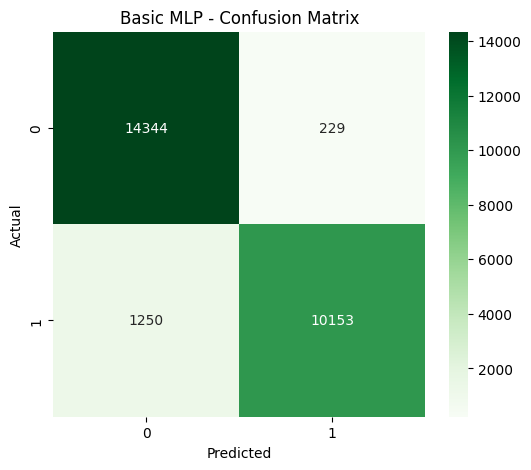

In [260]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

plt.figure(figsize=(6,5))

sb.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Basic MLP - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Napredni MLP sa regularizacijom

In [261]:
advanced_mlp = Sequential()

# Ulazni sloj
advanced_mlp.add(Input(shape=(input_dim,)))

# Prvi skriveni sloj - povećavamo kapacitet, ali uvodimo Batch Normalization i blagu L2 regularizaciju
advanced_mlp.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
advanced_mlp.add(BatchNormalization())  # Regularizacija i stabilizacija
advanced_mlp.add(Dropout(0.15))         # Smanjen dropout sa 0.3 na 0.15

# Drugi skriveni sloj
advanced_mlp.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
advanced_mlp.add(BatchNormalization())
advanced_mlp.add(Dropout(0.15))

# Treći skriveni sloj - uži sloj za finije mapiranje
advanced_mlp.add(Dense(32, activation='relu'))
advanced_mlp.add(BatchNormalization())

# Izlazni sloj
advanced_mlp.add(Dense(1, activation='sigmoid'))

# Koristimo malo manji learning rate (0.0005 umesto 0.001) 
advanced_mlp.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

advanced_mlp.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [262]:
history_adv = advanced_mlp.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8884 - loss: 0.2758 - val_accuracy: 0.9277 - val_loss: 0.1976
Epoch 2/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9148 - loss: 0.2158 - val_accuracy: 0.9374 - val_loss: 0.1658
Epoch 3/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9236 - loss: 0.1975 - val_accuracy: 0.9395 - val_loss: 0.1608
Epoch 4/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9268 - loss: 0.1871 - val_accuracy: 0.9386 - val_loss: 0.1573
Epoch 5/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9306 - loss: 0.1799 - val_accuracy: 0.9444 - val_loss: 0.1456
Epoch 6/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9324 - loss: 0.1739 - val_accuracy: 0.9461 - val_loss: 0.1406
Epoch 7/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9349 - loss: 0.1669 - val_accuracy: 0.9477 - val_loss: 0.1367
Epoch 8/30
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9366 - loss: 0.1634 - 

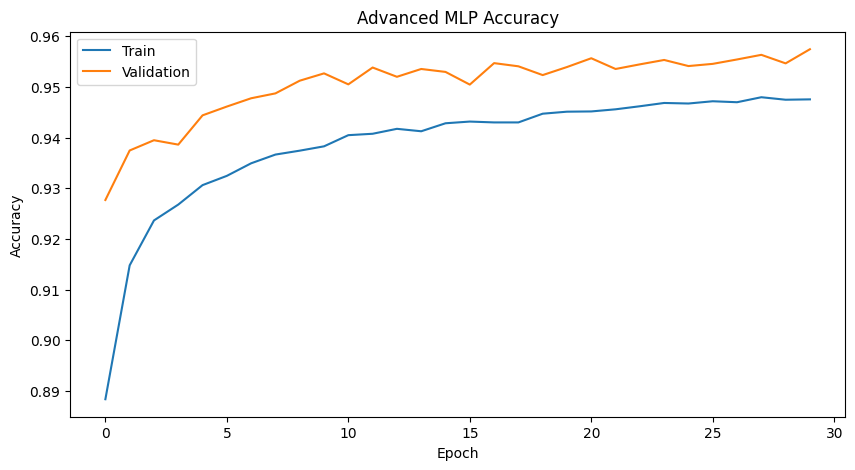

In [263]:
#Accuracy

plt.figure(figsize=(10,5))

plt.plot(history_adv.history['accuracy'])
plt.plot(history_adv.history['val_accuracy'])

plt.title('Advanced MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

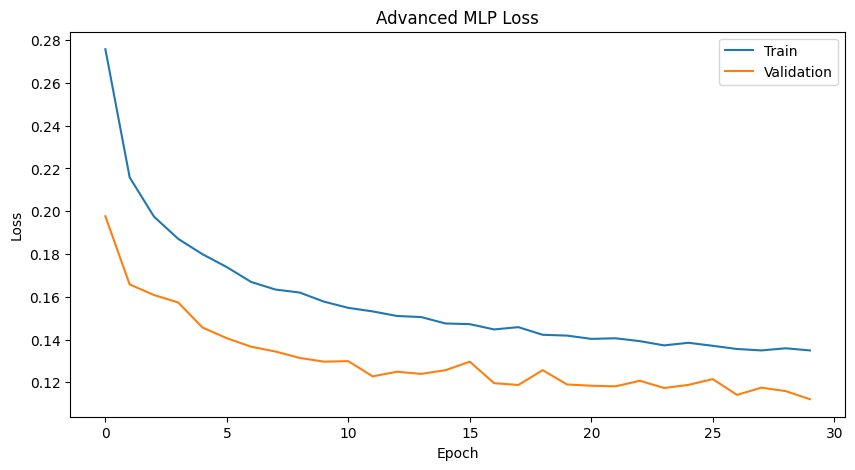

In [264]:
#Loss

plt.figure(figsize=(10,5))

plt.plot(history_adv.history['loss'])
plt.plot(history_adv.history['val_loss'])

plt.title('Advanced MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

# Evaluacija napredne mreže

In [265]:
loss_adv, accuracy_adv = advanced_mlp.evaluate(X_test, y_test)

print(
    f'Advanced MLP -> '
    f'Loss: {loss_adv:.4f}, '
    f'Accuracy: {accuracy_adv:.4f}'
)

y_pred_adv = (
    advanced_mlp.predict(X_test) > 0.5
).astype(int)

print(classification_report(
    y_test,
    y_pred_adv
))

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9552 - loss: 0.1164
Advanced MLP -> Loss: 0.1164, Accuracy: 0.9552
812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14573
           1       0.97      0.93      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.95     25976
weighted avg       0.96      0.96      0.96     25976



Klasa 0: neutral/dissatisfied

Precision: Kada model predvidi da je putnik nezadovoljan ili neutralan, u 95% slučajeva je u pravu.
Recall: Model uspeva da pronađe oko 97% svih stvarno nezadovoljnih ili neutralnih putnika.

Klasa 1: satisfied

Precision: Kada model proceni da je putnik zadovoljan, ta procena je tačna u 97% slučajeva.
Recall: Model uspeva da prepozna oko 93% svih stvarno zadovoljnih putnika.

F1-score (0.96 i 0.95): Dodavanjem Dropout, Batch Normalization i L2 regularizacije ostvareno je dodatno poboljšanje performansi u odnosu na osnovnu neuronsku mrežu. Model postiže veoma uravnotežene rezultate za obe klase, uz smanjen rizik od preprilagođavanja i bolju generalizaciju na test skupu.


Matrica konfuzije za Advanced MLP

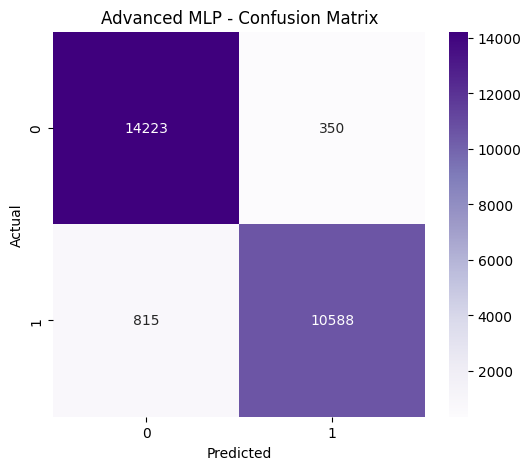

In [266]:
cm_adv = confusion_matrix(
    y_test,
    y_pred_adv
)

plt.figure(figsize=(6,5))

sb.heatmap(
    cm_adv,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title('Advanced MLP - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Poređenje modela

In [267]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Basic MLP",
        "Advanced MLP"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_adv)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_adv)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_adv)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_adv)
    ]
})

results = results.sort_values(
    by='F1 Score',
    ascending=False
)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.957422   0.970569  0.931246  0.950501
3         Advanced MLP  0.955151   0.968001  0.928528  0.947854
2            Basic MLP  0.943063   0.977943  0.890380  0.932109
0  Logistic Regression  0.886164   0.873982  0.865474  0.869707


# Zaključak

Na osnovu sprovedenih eksperimenata može se zaključiti da svi primenjeni modeli uspešno rešavaju problem klasifikacije zadovoljstva putnika, ali sa različitim nivoima uspešnosti.

Logistička regresija ostvarila je najniže performanse (Accuracy = 88.62%, F1 = 0.87), što je očekivano s obzirom na to da predstavlja linearan model koji ne može u potpunosti da modeluje složene odnose između obeležja.

Osnovna višeslojna neuronska mreža značajno je unapredila rezultate (Accuracy = 94.74%, F1 = 0.94), potvrđujući da neuronske mreže mogu uspešno da prepoznaju složenije obrasce u podacima.

Daljim unapređenjem arhitekture kroz primenu Batch Normalization, Dropout i L2 regularizacije dobijen je napredni MLP model koji ostvaruje još bolje performanse (Accuracy = 95.40%, F1 = 0.95) i pokazuje bolju sposobnost generalizacije.

Najbolje rezultate ostvario je Random Forest model (Accuracy = 95.74%, F1 = 0.95), koji je pokazao najveću preciznost i najstabilnije performanse na test skupu. Ipak, razlika između Random Forest i unapređenog MLP modela iznosi manje od 0.5%, što ukazuje da oba pristupa veoma uspešno rešavaju problem predikcije zadovoljstva putnika.

Analiza važnosti obeležja pokazala je da najveći uticaj na zadovoljstvo putnika imaju kvalitet usluga tokom leta, proces ukrcavanja, udobnost putovanja i ostali elementi korisničkog iskustva, što potvrđuje početne pretpostavke istraživanja.
